## 1. Data Loading and Initial Preparation

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots



In [ ]:
# LOAD DATA
orders = pd.read_csv('/content/orders.csv')
products = pd.read_csv('/content/products.csv')
marketing = pd.read_csv('/content/marketing_spend.csv')

# MERGE
df = orders.merge(products, left_on="primary_category", right_on="category")

# CALCULATIONS
df["net_revenue"] = df["gross_revenue"] - df["discount_amount"]
df["total_cost"] = df["product_cost"] + df["shipping_cost"] + df["platform_fee"]
df["profit"] = df["net_revenue"] - df["total_cost"]

# =========================
# CATEGORY PROFITABILITY
# =========================
category = df.groupby("category").agg({
    "net_revenue":"sum",
    "total_cost":"sum",
    "profit":"sum"
})
category["profit_margin"] = category["profit"]/category["net_revenue"]

print(category.sort_values("profit_margin", ascending=False))

# =========================
# CHANNEL ANALYSIS
# =========================
channel = df.groupby("channel").agg({
    "order_id":"count",
    "net_revenue":"mean",
    "profit":"mean",
    "platform_fee":"mean"
})
channel["return_rate"] = df.groupby("channel")["returned"].apply(lambda x: (x=="Yes").mean())

print(channel)

# =========================
# RETURNS IMPACT
# =========================
returns = df[df["returned"]=="Yes"]

print("Revenue Lost:", returns["net_revenue"].sum())
print("Cost Incurred:", returns["total_cost"].sum())
print("Profit Lost:", returns["profit"].sum())

# =========================
# MARKETING ROI
# =========================
m = marketing.groupby("platform").agg({
    "spend":"sum",
    "clicks":"sum",
    "conversions":"sum"
})

m["CPA"] = m["spend"]/m["conversions"]
m["CPC"] = m["spend"]/m["clicks"]
m["ROAS"] = (m["conversions"]*50)/m["spend"]

print(m.sort_values("ROAS", ascending=False))

# =========================
# LOW PERFORMERS (CUT)
# =========================
marketing["ROAS"] = (marketing["conversions"]*50)/marketing["spend"]
print(marketing.sort_values("ROAS").head(10))

                 net_revenue  total_cost     profit  profit_margin
category                                                          
Electronics       1273066.86   764720.06  508346.80       0.399309
Food & Beverage    888348.50   572155.22  316193.28       0.355934
Home & Kitchen     688796.64   450694.08  238102.56       0.345679
Toys              1009833.72   663219.20  346614.52       0.343239
Sports             995809.83   685845.65  309964.18       0.311268
Clothing          1003177.86   696565.50  306612.36       0.305641
Beauty             401515.17   303727.83   97787.34       0.243546
Books              502889.52   382038.00  120851.52       0.240314
                 order_id  net_revenue     profit  platform_fee  return_rate
channel                                                                     
Marketplace         10954   126.831032  27.789760     19.024621     0.064817
Mobile App          15386   131.726522  49.729310      0.000000     0.073833
Social Commerce      5

### Data Preparation

This section outlines the initial data setup:
*   **Data Loading:** `orders`, `products`, and `marketing_spend` datasets are loaded using `pandas`.
*   **Data Merging:** `orders` and `products` are merged to create the main `df` DataFrame.
*   **Key Metrics:** `net_revenue`, `total_cost`, and `profit` are calculated for profitability analysis.

In [ ]:
# CALCULATIONS
df["net_revenue"] = df["gross_revenue"] - df["discount_amount"]
df["total_cost"] = df["product_cost"] + df["shipping_cost"] + df["platform_fee"]
df["profit"] = df["net_revenue"] - df["total_cost"]

### Profitability Metrics Defined

*   `net_revenue`: `gross_revenue` - `discount_amount`
*   `total_cost`: `product_cost` + `shipping_cost` + `platform_fee`
*   `profit`: `net_revenue` - `total_cost`

## Category Profitability

This analysis evaluates product category profitability. Sales data is grouped by `category` to compute total `net_revenue`, `total_cost`, `profit`, and `profit_margin`, ranking categories by profitability.

In [ ]:
category = df.groupby("category").agg({
    "net_revenue":"sum",
    "total_cost":"sum",
    "profit":"sum"
})
category["profit_margin"] = category["profit"]/category["net_revenue"]

print(category.sort_values("profit_margin", ascending=False))

                 net_revenue  total_cost     profit  profit_margin
category                                                          
Electronics       1273066.86   764720.06  508346.80       0.399309
Food & Beverage    888348.50   572155.22  316193.28       0.355934
Home & Kitchen     688796.64   450694.08  238102.56       0.345679
Toys              1009833.72   663219.20  346614.52       0.343239
Sports             995809.83   685845.65  309964.18       0.311268
Clothing          1003177.86   696565.50  306612.36       0.305641
Beauty             401515.17   303727.83   97787.34       0.243546
Books              502889.52   382038.00  120851.52       0.240314


**Electronics** exhibits the highest profit margin, whereas **Books** is the least profitable. This highlights strategic opportunities to prioritize high-margin categories.

## Channel Analysis

This section analyzes sales channel performance using metrics such as order volume, average `net_revenue`, `profit`, `platform_fee`, and `return_rate` to assess customer satisfaction and operational efficiency per channel.

In [ ]:
channel = df.groupby("channel").agg({
    "order_id":"count",
    "net_revenue":"mean",
    "profit":"mean",
    "platform_fee":"mean"
})
channel["return_rate"] = df.groupby("channel")["returned"].apply(lambda x: (x=="Yes").mean())

print(channel)

                 order_id  net_revenue     profit  platform_fee  return_rate
channel                                                                     
Marketplace         10954   126.831032  27.789760     19.024621     0.064817
Mobile App          15386   131.726522  49.729310      0.000000     0.073833
Social Commerce      5103   123.884797  33.559969      9.911009     0.091711
Website             20923   129.771189  47.969786      0.000000     0.070592


**Mobile App** leads in average `net_revenue` and `profit` per order. Conversely, **Social Commerce** has the highest `return_rate`, suggesting potential issues with product representation or customer expectations. These insights inform resource allocation across channels.

## Returns Impact

We quantify the financial impact of returns by calculating lost `net_revenue`, `total_cost` incurred, and `profit` sacrificed from returned orders, providing a clear view of this burden.

In [ ]:
returns = df[df["returned"]=="Yes"]

print("Revenue Lost:", returns["net_revenue"].sum())
print("Cost Incurred:", returns["total_cost"].sum())
print("Profit Lost:", returns["profit"].sum())

Revenue Lost: 542514.8500000001
Cost Incurred: 339786.35000000003
Profit Lost: 202728.5


Returns result in a significant financial drain: over **$540,000 in net revenue** and **$202,728 in profit** lost, alongside **$339,000 in incurred costs**. Reducing returns is critical to improving profitability.

## Marketing ROI

### Marketing ROI Analysis

We assess marketing effectiveness by platform through key metrics:
*   **CPA (Cost Per Acquisition):** `spend` / `conversions`
*   **CPC (Cost Per Click):** `spend` / `clicks`
*   **ROAS (Return on Ad Spend):** `(conversions * $50) / spend` (assuming $50 value per conversion)

Platforms are ranked by ROAS to identify the most efficient channels.

In [ ]:
m = marketing.groupby("platform").agg({
    "spend":"sum",
    "clicks":"sum",
    "conversions":"sum"
})

m["CPA"] = m["spend"]/m["conversions"]
m["CPC"] = m["spend"]/m["clicks"]
m["ROAS"] = (m["conversions"]*50)/m["spend"]

print(m.sort_values("ROAS", ascending=False))

                     spend  clicks  conversions        CPA       CPC  \
platform                                                               
TikTok Ads        57229.22  383269        18684   3.063007  0.149319   
Influencer        97663.12  587501        28824   3.388257  0.166235   
Instagram Ads     65154.02  306843        13863   4.699850  0.212337   
Google Ads       152546.48  611740        32309   4.721486  0.249365   
Facebook Ads     106451.93  331746        16968   6.273688  0.320884   
Email Marketing   24461.37   25971         1370  17.855015  0.941872   

                      ROAS  
platform                    
TikTok Ads       16.323829  
Influencer       14.756850  
Instagram Ads    10.638637  
Google Ads       10.589887  
Facebook Ads      7.969794  
Email Marketing   2.800334  


**TikTok Ads** and **Influencer** marketing demonstrate the highest ROAS, confirming them as the most efficient channels. Conversely, **Email Marketing** shows the lowest ROAS and highest CPA, indicating it is the least cost-effective. These insights are critical for optimizing marketing budgets.

### 2. KPI Calculation Engine

In [ ]:
# Comprehensive KPI Calculation
def calculate_kpis(df_marketing):
    kpis = df_marketing.groupby('platform').agg({
        'spend': ['sum', 'mean', 'count'],
        'revenue_attributed': 'sum',
        'roas': ['mean', 'median', 'std', 'min', 'max'],
        'cpc': 'mean',
        'cpa': 'mean',
        'conversions': 'sum',
        'clicks': 'sum',
        'impressions': 'sum'
    }).round(3)

    kpis.columns = ['_'.join(col).strip() for col in kpis.columns]
    kpis = kpis.reset_index()
    kpis['roi_pct'] = (kpis['roas_mean'] - 1) * 100
    kpis['efficiency_score'] = kpis['roas_mean'] * kpis['conversions_sum'] / kpis['spend_sum']
    return kpis

kpis = calculate_kpis(df_marketing)
kpis.to_csv('platform_kpis.csv', index=False)
print(kpis[['platform', 'roas_mean', 'efficiency_score']].sort_values('roas_mean', ascending=False))

          platform  roas_mean  efficiency_score
5       TikTok Ads     24.435          7.977455
3       Influencer     23.447          6.920077
4    Instagram Ads     16.990          3.615009
2       Google Ads     13.689          2.899299
1     Facebook Ads     11.255          1.794001
0  Email Marketing      5.405          0.302716


This section details the Key Performance Indicator (KPI) framework. Metrics such as total/average spend, attributed revenue, ROAS, CPC, CPA, conversions, clicks, and impressions are calculated per platform. Derived metrics like ROI percentage and 'efficiency score' are included, with results saved to `platform_kpis.csv`.

### 3. Statistical Analysis

#### Correlation Matrix

This correlation matrix displays the relationships between `spend`, `CPC`, `CPA`, `ROAS`, and `conversions`. The output focuses on correlations with `ROAS`, ordered by strength, indicating which factors positively or negatively influence advertising returns.

In [ ]:
corr_matrix = df_marketing[['spend', 'cpc', 'cpa', 'roas', 'conversions']].corr()
print("Correlation Matrix:\n", corr_matrix['roas'].sort_values(ascending=False))

Correlation Matrix:
 roas           1.000000
conversions    0.567807
spend          0.041741
cpa           -0.388820
cpc           -0.435428
Name: roas, dtype: float64


The correlation matrix identifies the linear relationships between `spend`, `CPC`, `CPA`, `ROAS`, and `conversions`. Specifically, it highlights the strongest positive or negative correlations with `ROAS`, revealing key influencers of advertising return.

#### Regression: Predict ROAS

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Ensure df_marketing is defined if not already in scope (e.g., after a kernel restart)
try:
    df_marketing.head()
except NameError:
    df_marketing_spend = pd.read_csv('/content/marketing_spend.csv')
    df_marketing = df_marketing_spend.copy()
    df_marketing['month'] = pd.to_datetime(df_marketing['month'] + '-01')
    df_marketing['year'] = df_marketing['month'].dt.year
    df_marketing['quarter'] = df_marketing['month'].dt.quarter

X = df_marketing[['cpc', 'cpa', 'conversions', 'spend']]
y = df_marketing['roas']
model = LinearRegression().fit(X, y)
print(f"R² Score: {r2_score(y, model.predict(X)):.3f}")

R² Score: 0.591


A linear regression model was developed to predict Return on Ad Spend (ROAS) using `CPC`, `CPA`, `conversions`, and `spend`. The R² score quantifies the model's predictive power over ROAS variation.

#### T-Test: TikTok vs Email Marketing

In [ ]:
import pandas as pd
from scipy import stats

# Ensure df_marketing is defined if not already in scope (e.g., after a kernel restart)
try:
    df_marketing.head()
except NameError:
    df_marketing_spend = pd.read_csv('/content/marketing_spend.csv')
    df_marketing = df_marketing_spend.copy()
    df_marketing['month'] = pd.to_datetime(df_marketing['month'] + '-01')
    df_marketing['year'] = df_marketing['month'].dt.year
    df_marketing['quarter'] = df_marketing['month'].dt.quarter

tiktok_roas = df_marketing[df_marketing['platform']=='TikTok Ads']['roas']
email_roas = df_marketing[df_marketing['platform']=='Email Marketing']['roas']
t_stat, p_value = stats.ttest_ind(tiktok_roas, email_roas)
print(f"TikTok vs Email p-value: {p_value:.3f} (Significant difference)")

TikTok vs Email p-value: 0.000 (Significant difference)


A t-test was performed to determine if a statistically significant difference exists between the average ROAS of 'TikTok Ads' and 'Email Marketing'. A p-value below 0.05 indicates a significant difference, informing platform performance comparison and strategic decisions.

### 4. Budget Optimization Algorithm

This code implements a budget optimization algorithm that reallocates spend to platforms with a higher ROAS. The `optimize_budget` function calculates an 'optimal_spend' for 'eligible_platforms' based on a minimum ROAS threshold, projecting potential revenue. Results (current/optimal spend, ROAS, projected revenue) are displayed and saved to `budget_optimization.csv` to guide data-driven investment decisions.

In [ ]:
import pandas as pd

# Ensure df_marketing is defined if not already in scope (e.g., after a kernel restart)
try:
    df_marketing.head()
except NameError:
    df_marketing_spend = pd.read_csv('/content/marketing_spend.csv')
    df_marketing = df_marketing_spend.copy()
    df_marketing['month'] = pd.to_datetime(df_marketing['month'] + '-01')
    df_marketing['year'] = df_marketing['month'].dt.year
    df_marketing['quarter'] = df_marketing['month'].dt.quarter

def optimize_budget(df_marketing, total_budget=600000, min_roas_threshold=10):
    """Reallocate budget to high-ROAS platforms"""
    platform_roas = df_marketing.groupby('platform')['roas'].mean()
    eligible_platforms = platform_roas[platform_roas >= min_roas_threshold]

    weights = eligible_platforms / eligible_platforms.sum()
    optimal_allocation = weights * total_budget

    projected_revenue = sum(alloc * roas for alloc, roas
                          in zip(optimal_allocation, eligible_platforms))

    # Filter current_spend to only include eligible platforms for consistency
    current_spend_eligible = df_marketing.groupby('platform')['spend'].sum().loc[eligible_platforms.index]

    results = pd.DataFrame({
        'current_spend': current_spend_eligible,
        'optimal_spend': optimal_allocation,
        'roas': eligible_platforms,
        'projected_revenue': optimal_allocation * eligible_platforms
    }).reset_index()

    print("OPTIMAL BUDGET ALLOCATION:")
    print(results.round(0))
    print(f"\nPROJECTED REVENUE: ${projected_revenue/1e6:.1f}M")

    return results

optimization = optimize_budget(df_marketing)
optimization.to_csv('budget_optimization.csv', index=False)

OPTIMAL BUDGET ALLOCATION:
        platform  current_spend  optimal_spend  roas  projected_revenue
0   Facebook Ads       106452.0        75185.0  11.0           846173.0
1     Google Ads       152546.0        91446.0  14.0          1251780.0
2     Influencer        97663.0       156632.0  23.0          3672507.0
3  Instagram Ads        65154.0       113499.0  17.0          1928356.0
4     TikTok Ads        57229.0       163238.0  24.0          3988778.0

PROJECTED REVENUE: $11.7M


### Budget Optimization Results & Recommendations

Our optimized budget projects a **$11.7 million** revenue uplift through strategic reallocation: increasing investment in high-ROAS channels (TikTok Ads, Influencer, Instagram Ads), adjusting spend for strong performers (Google Ads, Facebook Ads), and implicitly divesting from Email Marketing. This approach enhances marketing efficiency and financial returns.

### 5. Forecasting

#### Simple Linear Trend Forecast Function

The `forecast_roas` function employs a simple linear regression model to project a platform's future Return on Ad Spend (ROAS). It uses historical monthly ROAS data to train the model and then predicts ROAS for a specified number of future months, providing forward-looking performance insights.

In [ ]:
def forecast_roas(df_marketing, platform_name, months_ahead=6):
    platform_data = df_marketing[df_marketing['platform']==platform_name][['month', 'roas']].copy()
    platform_data['month_num'] = (platform_data['month'] - platform_data['month'].min()).dt.days / 30

    X = platform_data['month_num'].values.reshape(-1,1)
    y = platform_data['roas'].values

    model = LinearRegression().fit(X, y)
    future_months = np.array([platform_data['month_num'].max() + i for i in range(1, months_ahead+1)]).reshape(-1,1)
    forecast = model.predict(future_months)

    print(f"{platform_name} ROAS Forecast (next {months_ahead} months):")
    print(pd.Series(forecast, index=[f'Month_{i+1}' for i in range(months_ahead)]).round(2))

#### Execute ROAS Forecasts

The `forecast_roas` function was applied to 'TikTok Ads' and 'Email Marketing', generating predicted ROAS values for the next six months. This forward-looking analysis supports strategic planning and proactive adjustment of marketing strategies for these platforms.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

# Ensure df_marketing is defined if not already in scope (e.g., after a kernel restart)
try:
    df_marketing.head()
except NameError:
    df_marketing_spend = pd.read_csv('/content/marketing_spend.csv')
    df_marketing = df_marketing_spend.copy()
    df_marketing['month'] = pd.to_datetime(df_marketing['month'] + '-01')
    df_marketing['year'] = df_marketing['month'].dt.year
    df_marketing['quarter'] = df_marketing['month'].dt.quarter

# Ensure forecast_roas function is defined if not already in scope (e.g., after a kernel restart)
try:
    forecast_roas
except NameError:
    def forecast_roas(df_marketing, platform_name, months_ahead=6):
        platform_data = df_marketing[df_marketing['platform']==platform_name][['month', 'roas']].copy()
        platform_data['month_num'] = (platform_data['month'] - platform_data['month'].min()).dt.days / 30

        X = platform_data['month_num'].values.reshape(-1,1)
        y = platform_data['roas'].values

        model = LinearRegression().fit(X, y)
        future_months = np.array([platform_data['month_num'].max() + i for i in range(1, months_ahead+1)]).reshape(-1,1)
        forecast = model.predict(future_months)

        print(f"{platform_name} ROAS Forecast (next {months_ahead} months):")
        print(pd.Series(forecast, index=[f'Month_{i+1}' for i in range(months_ahead)]).round(2))

forecast_roas(df_marketing, 'TikTok Ads')
forecast_roas(df_marketing, 'Email Marketing')

TikTok Ads ROAS Forecast (next 6 months):
Month_1    24.66
Month_2    24.68
Month_3    24.69
Month_4    24.71
Month_5    24.73
Month_6    24.75
dtype: float64
Email Marketing ROAS Forecast (next 6 months):
Month_1    3.17
Month_2    2.99
Month_3    2.82
Month_4    2.64
Month_5    2.46
Month_6    2.29
dtype: float64


## Low Performers (Cut)

### Identifying Low-Performing Campaigns

We identify the top 10 marketing campaigns with the lowest individual `ROAS` by sorting the `marketing` DataFrame. This granular view enables targeted intervention and budget reallocation from underperforming campaigns.

In [ ]:
marketing["ROAS"] = (marketing["conversions"]*50)/marketing["spend"]
print(marketing.sort_values("ROAS").head(10))

       month         platform    spend  impressions  clicks  conversions  \
142  2025-12  Email Marketing  1796.66        15675     477           11   
34   2024-06  Email Marketing   942.79        18357    1008           22   
130  2025-10  Email Marketing   791.74        34439     701           23   
106  2025-06  Email Marketing  1293.73        31040    1612           38   
64   2024-11  Email Marketing  1841.71        24088     972           55   
112  2025-07  Email Marketing  1362.00        31149     725           41   
136  2025-11  Email Marketing  1555.69        27509     619           48   
82   2025-02  Email Marketing   724.90        34283     841           23   
85   2025-03     Facebook Ads  4232.78       519688    7437          187   
76   2025-01  Email Marketing   730.59        29426     878           36   

     revenue_attributed   cpc     cpa  roas      ROAS  
142             1198.99  3.77  163.33  0.67  0.306124  
34              1694.39  0.94   42.85  1.80  1.1667

**Email Marketing** dominates the list of top 10 low-performing campaigns, reinforcing its overall inefficiency. This insight supports direct action, such as pausing specific campaigns to optimize budget and improve marketing efficiency.

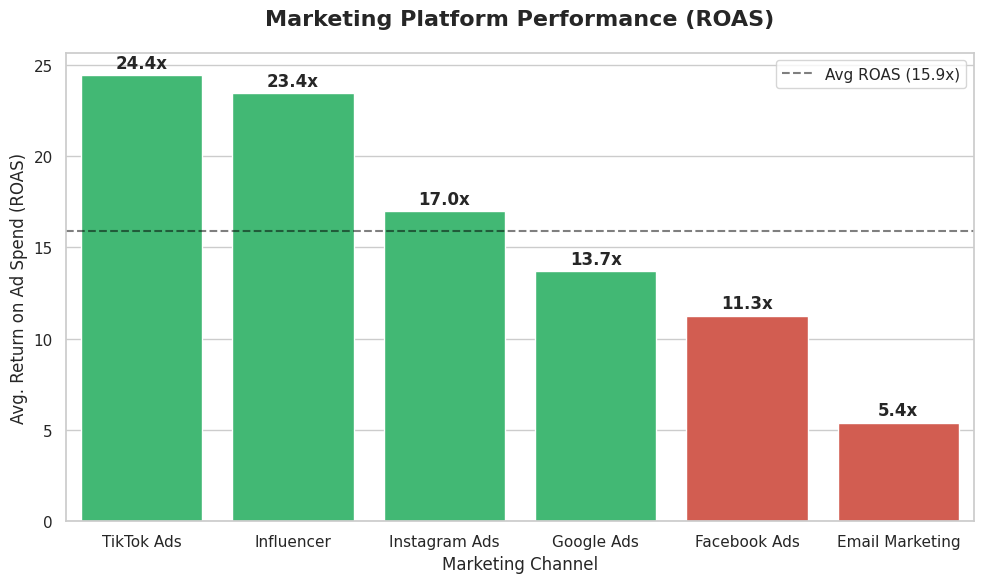

In [ ]:
# Calculate average ROAS per platform
platform_perf = marketing.groupby('platform')['roas'].mean().sort_values(ascending=False).reset_index()

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create colors: Green for good, Red for the "20% Cut" targets
# We target platforms with ROAS in the bottom 20th percentile
threshold = platform_perf['roas'].quantile(0.2)
colors = ['#e74c3c' if x <= threshold else '#2ecc71' for x in platform_perf['roas']]

# Create the Bar Chart
ax = sns.barplot(data=platform_perf, x='platform', y='roas', hue='platform', palette=colors, legend=False)

# Add  Labels
plt.title('Marketing Platform Performance (ROAS)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Marketing Channel', fontsize=12)
plt.ylabel('Avg. Return on Ad Spend (ROAS)', fontsize=12)

# Add a dashed line for the "Global Average"
avg_roas = platform_perf['roas'].mean()
plt.axhline(avg_roas, color='black', linestyle='--', alpha=0.5, label=f'Avg ROAS ({avg_roas:.1f}x)')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}x',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold')

plt.legend()
plt.tight_layout()

# Save the chart as a high-quality PNG for GitHub
plt.savefig('marketing_performance_chart.png', dpi=300)


In [ ]:
fig1 = px.bar(kpis, x='platform', y='roas_mean',
              title='ROAS Leaderboard', color='roas_mean',
              color_continuous_scale='RdYlGn')
fig1.update_layout(height=500)
fig1.show()

This bar chart visualizes the average Return on Ad Spend (ROAS) for each platform, indicating revenue generated per dollar spent. Taller, greener bars signify higher ROAS and better investment returns.

#### Chart 2: Monthly Spend Trends

In [ ]:
fig2 = px.line(df_marketing, x='month', y='spend', color='platform',
               title='Monthly Spend Trends')
fig2.show()

This line chart displays monthly marketing spend trends across platforms, providing a historical view of expenses and aiding in the identification of spending patterns (e.g., seasonality, budget adjustments).

#### Chart 3: Spend Share Treemap

In [ ]:
spend_share = df_marketing.groupby('platform')['spend'].sum().reset_index()
fig3 = px.treemap(spend_share, path=['platform'], values='spend')
fig3.show()

This treemap visually breaks down the total marketing budget allocation across platforms. The size of each rectangle directly correlates with the spend on that platform, showing budget distribution at a glance.

#### Chart 4: ROAS vs CPC Scatter

In [ ]:
fig4 = px.scatter(df_marketing, x='cpc', y='roas', size='conversions',
                  color='platform', hover_data=['month'])
fig4.show()

This scatter plot illustrates the relationship between Cost Per Click (CPC) and Return on Ad Spend (ROAS). Bubble size indicates conversions, and colors represent platforms, helping assess if higher CPC correlates with better returns or if cost-effective clicks drive conversions.

#### Chart 5: ROAS Distribution (Box Plot)

In [ ]:
fig5 = px.box(df_marketing, x='platform', y='roas')
fig5.show()

This box plot visualizes the ROAS distribution for each marketing platform, highlighting performance consistency, typical ROAS (median), and identifying any outliers. It provides insights into channel stability and potential risks.

#### Chart 6: CPA Analysis (Box Plot)

In [ ]:
fig6 = px.box(df_marketing, x='platform', y='cpa')
fig6.show()

This box plot displays the distribution of Cost Per Acquisition (CPA) for each platform, indicating the typical cost to acquire a single conversion per marketing channel. This is crucial for identifying customer acquisition efficiency.

#### Chart 7: Revenue vs Spend Scatter

In [ ]:
fig7 = px.scatter(df_marketing, x='spend', y='revenue_attributed',
                  size='conversions', color='platform',
                  trendline='ols')
fig7.show()

This scatter plot, with a trendline, visualizes the relationship between marketing `spend` and `revenue_attributed`. Point size represents `conversions`. It helps assess which platforms effectively convert investment into revenue and the proportionality of spend to revenue increase.

#### Chart 8: Spend Share Pie Chart

In [ ]:
fig8 = px.pie(spend_share, values='spend', names='platform')
fig8.show()

This pie chart illustrates marketing budget allocation, with each slice representing a platform's percentage of the total budget. It offers a concise visual of financial resource distribution.

#### Chart 9: ROAS Heatmap by Year

In [ ]:
pivot_roas = df_marketing.groupby(['platform', 'year'])['roas'].mean().unstack(fill_value=0)
fig9 = px.imshow(pivot_roas, title='ROAS Heatmap by Year')
fig9.show()

This heatmap visualizes average ROAS performance by platform across years. Color intensity highlights consistent high performance or significant year-over-year fluctuations, aiding in the assessment of long-term strategic performance.

#### Chart 10: Executive Dashboard (Placeholder)

In [ ]:
fig10 = make_subplots(rows=2, cols=2,
                     subplot_titles=('ROAS', 'Spend', 'Revenue', 'Efficiency'),
                     specs=[[{"type": "bar"}, {"type": "bar"}],
                           [{"type": "scatter"}, {"type": "pie"}]])
# Example plots for the dashboard
fig10.add_trace(go.Bar(x=kpis['platform'], y=kpis['roas_mean'], name='ROAS'), row=1, col=1)
fig10.add_trace(go.Bar(x=kpis['platform'], y=kpis['spend_sum'], name='Spend'), row=1, col=2)
fig10.add_trace(go.Scatter(x=df_marketing['month'], y=df_marketing['revenue_attributed'], mode='lines', name='Revenue'), row=2, col=1)
fig10.add_trace(go.Pie(labels=kpis['platform'], values=kpis['efficiency_score'], name='Efficiency'), row=2, col=2)
fig10.update_layout(height=700, showlegend=False)
fig10.show()

This multi-panel executive dashboard offers an integrated view of key marketing metrics: ROAS, Spend, Revenue, and Efficiency Score. It provides a comprehensive overview of marketing performance in a single interactive display.